In [ ]:
import numpy as np
import pandas as pd
import data_utils_clean
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer,KNNImputer,MissingIndicator
from sklearn.preprocessing import OneHotEncoder,StandardScaler,LabelEncoder,MinMaxScaler,PowerTransformer,OrdinalEncoder
from sklearn.model_selection import train_test_split

In [ ]:
!pip install dagshub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.2/261.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 5.7 MB/s eta 0:00:00


In [ ]:
!pip install mlflow dagshub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.2/676.2 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.6/201.6 kB 14.0 MB/s eta 0:00:00


In [ ]:
import dagshub
dagshub.init(repo_owner='sneha12603',repo_name='Delivery-time-prediction',mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=b5409e87-1add-4064-a125-70c19640bee2&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=5ffe68eb60fcc29be2f41f8cbfb3cf57f0bc113f8e9241670adddf0a3165d00c




Output()

Accessing as sneha12603

Initialized MLflow to track repo "sneha12603/Delivery-time-prediction"

Repository sneha12603/Delivery-time-prediction initialized!

In [ ]:
import mlflow

In [ ]:
mlflow.set_tracking_uri("https://dagshub.com/sneha12603/Delivery-time-prediction.mlflow")

In [ ]:
mlflow.set_experiment("Exp 4 - LGBM HP Tuning")

<Experiment: artifact_location='mlflow-artifacts:/061d945658294dff83e31a0fa8e46bec', creation_time=1752529358076, experiment_id='4', last_update_time=1752529358076, lifecycle_stage='active', name='Exp 4 - LGBM HP Tuning', tags={}>

In [ ]:
from sklearn import set_config
set_config(transform_output='pandas')

In [ ]:
df = pd.read_csv('swiggy.csv')

In [ ]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [ ]:
data_utils_clean.perform_data_cleaning(df)

In [ ]:
#load the cleaned data
df = pd.read_csv('swiggy_cleaned.csv')

In [ ]:
df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846,short
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,CHEN,11,3,friday,0,15.0,23.0,night,4.657195,short
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393,medium


In [ ]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [ ]:
#drop the columns not required for model input
columns_to_drop = ['rider_id',
                   'restaurant_latitude',
                   'restaurant_longitude',
                   'delivery_latitude',
                   'delivery_longitude',
                   'order_date',
                   'order_time_hour',
                   'order_day',
                   'city_name',
                   'order_day_of_week',
                   'order_month']

df.drop(columns=columns_to_drop,inplace=True)
df

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,30.0,4.8,windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,0,10.0,morning,1.489846,short
45498,21.0,4.6,windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,36,0,15.0,evening,NaN,NaN
45499,30.0,4.9,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,0,15.0,night,4.657195,short
45500,20.0,4.7,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,0,5.0,afternoon,6.232393,medium


In [ ]:
#check for missing values
df.isna().sum()

,0
age,1854
ratings,1908
weather,525
traffic,510
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,993
festival,228
city_type,1198


In [ ]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

<Axes: >

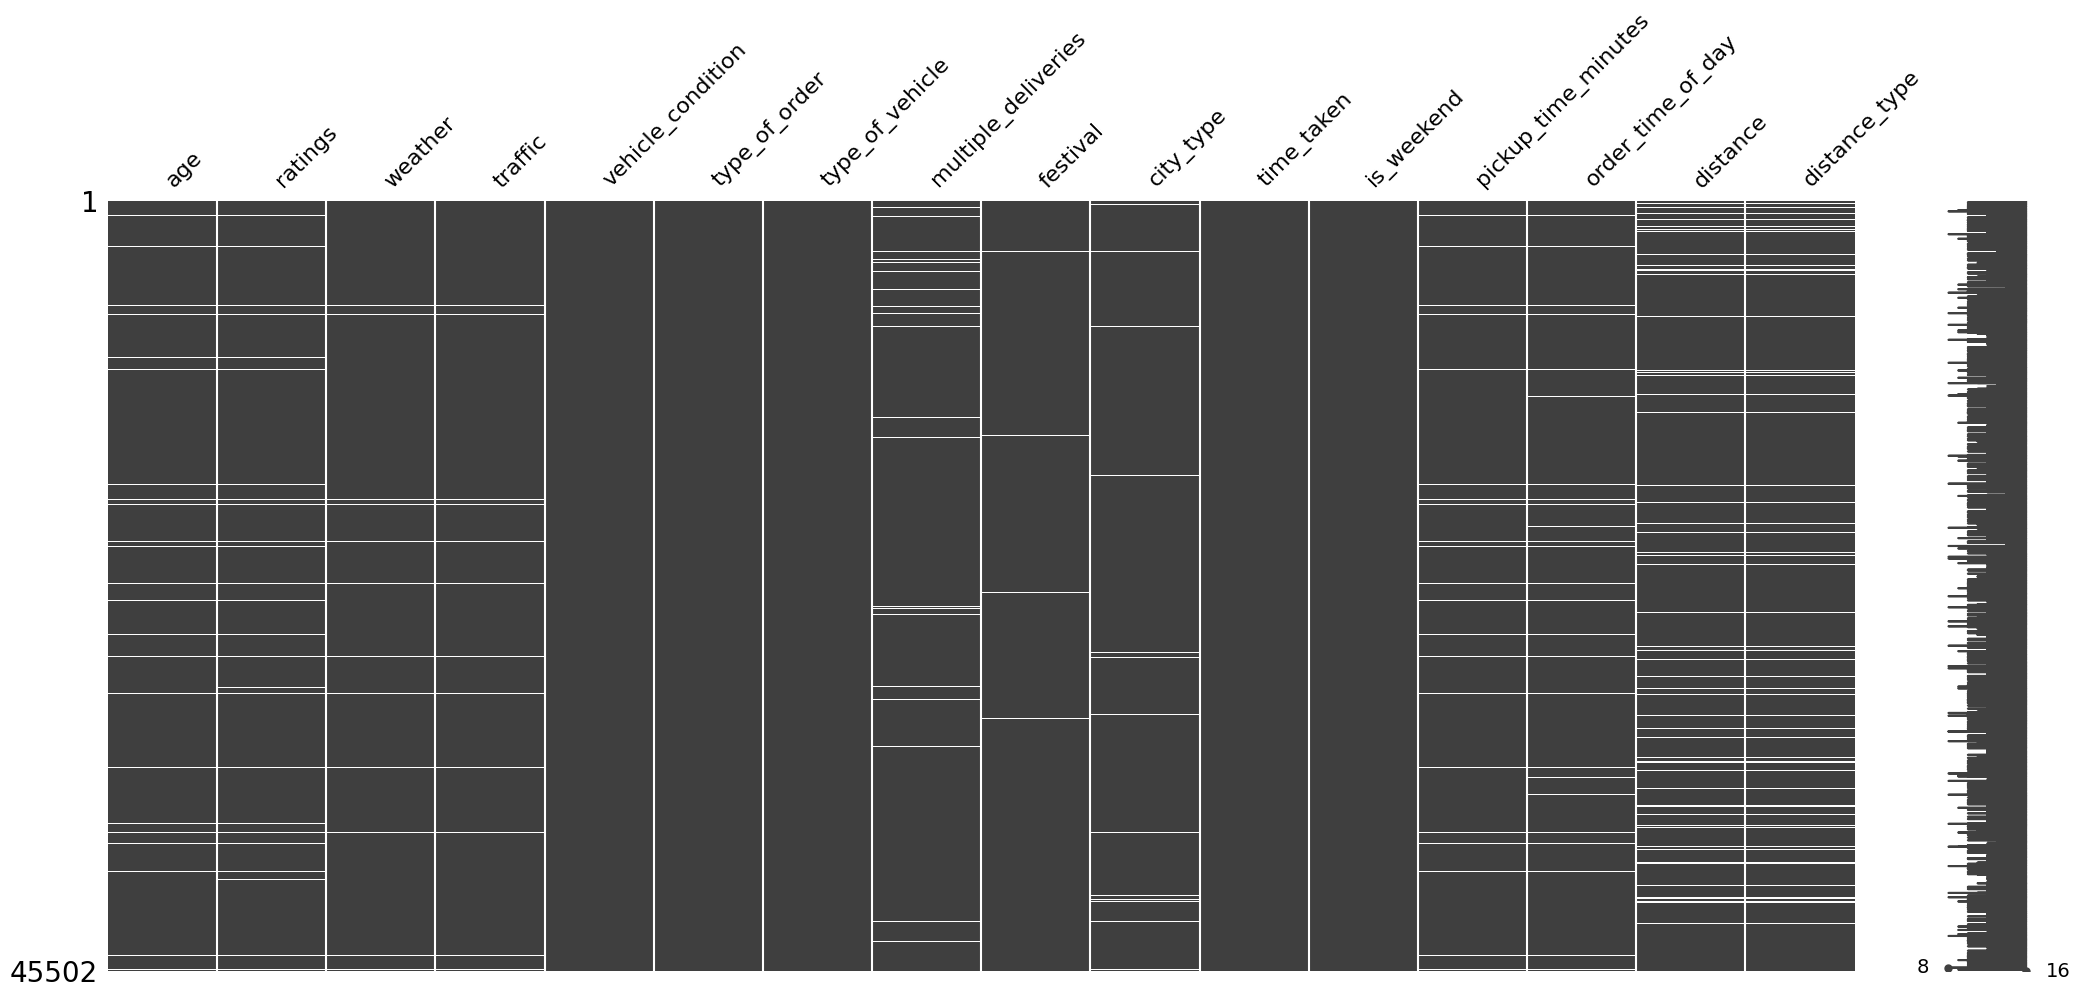

In [ ]:
import missingno as msno
msno.matrix(df)

In [ ]:
#columns that have missing values
missing_cols = (
    df.isna().any(axis=0).loc[lambda x:x].index
)

missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

***Drop missing values***

In [ ]:
temp_df = df.copy().dropna()

In [ ]:
#split into X and y
X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print("The size of train data is",X_train.shape)
print("The size of test data is",X_test.shape)

The size of train data is (30156, 15)
The size of test data is (7539, 15)


In [ ]:
#missing values in train data
X_train.isna().sum()

,0
age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,0
city_type,0


In [ ]:
#transfor target column
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [ ]:
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [ ]:
#percentage of rows in data havinf=g missing values
(X_train.isna().any(axis=1).mean().round(2)*100)

np.float64(0.0)

**Preprocessing technique**

In [ ]:
num_cols = ['age','ratings','pickup_time_minutes','distance']

nominal_cat_cols = ['weather',
                    'type_of_order',
                    'type_of_vehicle',
                    'festival',
                    'city_type',
                    'is_weekend',
                    'order_time_of_day']

ordinal_cat_columns = ['traffic','distance_type']

In [ ]:
nominal_cat_cols

['weather',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'is_weekend',
 'order_time_of_day']

In [ ]:
X_train.isna().sum()

,0
age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,0
city_type,0


In [ ]:
#do basic preprocessing
num_cols = ['age','ratings','pickup_time_minutes','distance']

nominal_cat_cols = ['weather','type_of_order',
                    'type_of_vehicle','festival',
                    'city_type',
                    'is_weekend',
                    'order_time_of_day']

ordinal_cat_cols = ['traffic','distance_type']

In [ ]:
#generate order for ordinal encoding
traffic_order = ['low','medium','high','jam']
distance_type_order = ['short','medium','long','very_long']

In [ ]:
#unique categories of ordinal columns
for col in ordinal_cat_cols:
  print(col,X_train[col].unique())

traffic ['jam' 'medium' 'high' 'low']
distance_type ['medium' 'short' 'long' 'very_long']


In [ ]:
#build a preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('scale',MinMaxScaler(),num_cols),
    ('nominal_encode',OneHotEncoder(drop='first',handle_unknown='ignore',
                                    sparse_output = False),nominal_cat_cols),
    ('ordinal_cat_cols',OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                       encoded_missing_value=-999,
                                       handle_unknown='use_encoded_value',
                                       unknown_value=-1),ordinal_cat_cols)
],remainder='passthrough',n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

In [ ]:
#buils the pipeline
processing_pipeline = Pipeline(steps=[
    ('preprocess',preprocessor)
])

processing_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                                   remainder='passthrough',
                                   transformers=[('scale', MinMaxScaler(),
                                                  ['age', 'ratings',
                                                   'pickup_time_minutes',
                                                   'distance']),
                                                 ('nominal_encode',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['weather', 'type_of_order',
                                                   'type_of_vehicle',
                                                   'festival', 'city_type',
                                                   'is_weekend',
                                                   'order_time_of_day']),
                                                 ('ordinal_cat_cols',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 encoded_missing_value=-999,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['traffic',
                                                   'distance_type'])],
                                   verbose_feature_names_out=False))])

In [ ]:
#do data preprocessing
X_train_trans = processing_pipeline.fit_transform(X_train)

X_test_trans = processing_pipeline.transform(X_test)

In [ ]:
X_train_trans

,age,ratings,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,type_of_order_drinks,...,city_type_semi-urban,city_type_urban,is_weekend_1,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,traffic,distance_type,vehicle_condition,multiple_deliveries
8708,0.473684,0.56,1.0,0.404165,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,0,2.0
25198,1.000000,0.76,0.0,0.154044,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,1.0
34049,0.473684,0.80,0.5,0.002461,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1,0.0
25987,1.000000,0.92,1.0,0.460411,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0,1.0
37121,0.526316,0.76,0.5,0.243676,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20239,0.578947,0.92,0.5,0.451895,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,3.0,2.0,0,0.0
7590,0.052632,1.00,1.0,0.612270,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,2.0,1,1.0
13610,0.526316,0.92,0.0,0.322877,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1,0.0
1045,0.947368,0.96,0.5,0.004486,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0,1.0


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 7.3 MB/s eta 0:00:00


In [ ]:
from lightgbm import LGBMRegressor
import optuna

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.compose import TransformedTargetRegressor

In [ ]:
def objective(trial):
  with mlflow.start_run(nested=True):
    params = {
        'n_estimators': trial.suggest_int('n_estimators',10,200),
        'max_depth':trial.suggest_int('max_depth',1,40),
        'learning_rate':trial.suggest_float('learning_rate',0.1,0.8),
        'subsample':trial.suggest_float('subsample',0.5,1),
        'min_child_weight':trial.suggest_int('min_chile_weight',5,20),
        'min_split_gain':trial.suggest_float('min_split_gain',0,10),
        'reg_lamda':trial.suggest_float('reg_lamda',0,100),
        'random_state':42,
        'n_jobs':-1
    }

    #log model parameters
    mlflow.log_params(params)

    xgb_reg = LGBMRegressor(**params)
    model = TransformedTargetRegressor(regressor=xgb_reg,transformer=pt)

    #train the model
    model.fit(X_train_trans,y_train)

    #get the predictions
    y_pred_train = model.predict(X_train_trans)
    y_pred_test = model.predict(X_test_trans)

    #perform cross validation
    cv_score = cross_val_score(model,X_train_trans,y_train,cv=5,scoring='neg_mean_absolute_error',n_jobs=-1)

    #mean score
    mean_score = -(cv_score.mean())
    #log avg cross val error
    mlflow.log_metric('cross_val_error',mean_score)

    return mean_score

In [ ]:
#create optuna study
study = optuna.create_study(direction='minimize')

with mlflow.start_run(run_name='best_model'):
  #optimimze the objective function
  study.optimize(objective,n_trials=50,n_jobs=-1,show_progress_bar=True)

  #log the best parameters
  mlflow.log_params(study.best_params)

  #log the best score
  mlflow.log_metric("best_score",study.best_value)

  #train the model on best parameters
  best_lgbm = LGBMRegressor(**study.best_params)

  best_lgbm.fit(X_train_trans,y_train_pt.values.ravel())

  #get the predictions
  y_pred_train_pt = best_lgbm.predict(X_train_trans)
  y_pred_test_pt = best_lgbm.predict(X_test_trans)

  #inverse transform the predictions
  y_pred_train_org = pt.inverse_transform(y_pred_train_pt.reshape(-1,1))
  y_pred_test_org = pt.inverse_transform(y_test_pt.values.reshape(-1,1))

  #perfrorm cross validation
  model = TransformedTargetRegressor(regressor=best_lgbm,transformer=pt)

  scores = cross_val_score(model,X_train_trans,y_train,scoring='neg_mean_absolute_error',cv=5,n_jobs=-1)

  #log metrics
  mlflow.log_metric('training_error',mean_absolute_error(y_train,y_pred_train_org))
  mlflow.log_metric('test_error',mean_absolute_error(y_test,y_pred_test_org))
  mlflow.log_metric('r2_score_train',r2_score(y_train,y_pred_train_org))
  mlflow.log_metric('r2_score_test',r2_score(y_test,y_pred_test_org))
  mlflow.log_metric('cross_val',- scores.mean())

  #log the best model
  #mlflow.sklearn.log_model(best_lgbm,artifact_path='model') # Removed this line

[I 2025-07-24 10:47:49,289] A new study created in memory with name: no-name-1ed10b80-5eb6-48d4-a55d-08a33fa58b5f


  0%|          | 0/50 [00:00<?, ?it/s]

🏃 View run big-ram-952 at: https://dagshub.com/sneha12603/Delivery-time-prediction.mlflow/#/experiments/4/runs/7fbf0fc9863b4912a4e392be67001ee4
🧪 View experiment at: https://dagshub.com/sneha12603/Delivery-time-prediction.mlflow/#/experiments/4
[I 2025-07-24 10:48:02,031] Trial 1 finished with value: 3.5585537684049884 and parameters: {'n_estimators': 101, 'max_depth': 14, 'learning_rate': 0.40337345164384697, 'subsample': 0.7502322741940681, 'min_chile_weight': 19, 'min_split_gain': 3.731294149202773, 'reg_lamda': 82.4236558088755}. Best is trial 1 with value: 3.5585537684049884.
🏃 View run brawny-stag-835 at: https://dagshub.com/sneha12603/Delivery-time-prediction.mlflow/#/experiments/4/runs/be5a11d7ef61425485a06cdeae07eca6
🧪 View experiment at: https://dagshub.com/sneha12603/Delivery-time-prediction.mlflow/#/experiments/4
[I 2025-07-24 10:48:02,139] Trial 0 finished with value: 3.7148858499071196 and parameters: {'n_estimators': 95, 'max_depth': 30, 'learning_rate': 0.46630413295729

In [ ]:
study.best_params

{'n_estimators': 32,
 'max_depth': 38,
 'learning_rate': 0.19180137911248882,
 'subsample': 0.7071645112302646,
 'min_chile_weight': 7,
 'min_split_gain': 0.005365828476410886,
 'reg_lamda': 8.308142160805943}

In [ ]:
study.best_value

3.1115292567084847

In [ ]:
#optimization history plot
optuna.visualization.plot_optimization_history(study)

In [ ]:
#plot hyperparameter importance plot
optuna.visualization.plot_param_importances(study)

In [ ]:
#slice plot
optuna.visualization.plot_slice(study)